In [90]:
import pandas as pd
df = pd.read_csv("UK-unemployment-data.csv", skiprows=7)
df.head(10)

,Important notes,Unnamed: 1
0,1971,4.1
1,1972,4.3
2,1973,3.7
3,1974,3.7
4,1975,4.5
5,1976,5.4
6,1977,5.6
7,1978,5.5
8,1979,5.4
9,1980,6.8


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 933 entries, 0 to 932
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Important notes  933 non-null    object 
 1   Unnamed: 1       933 non-null    float64
dtypes: float64(1), object(1)
memory usage: 14.7+ KB


# Data Cleaning

In [92]:
# keep correct header names while removing the unnecessary info at the start
df.columns = ["Date", "Unemployment rate (%)"]
df

,Date,Unemployment rate (%)
0,1971,4.1
1,1972,4.3
2,1973,3.7
3,1974,3.7
4,1975,4.5
...,...,...
928,2025 JUL,4.8
929,2025 AUG,5.0
930,2025 SEP,5.1
931,2025 OCT,5.1


## Quarterly rates over the last decade

In [93]:
quarterly_df = df[df["Date"].str.match(r"^\d{4} Q[1-4]$", na=False)]
quarterly_df["Year"] = quarterly_df["Date"].str[:4].astype(int)
quarterly_df["Quarter"] = quarterly_df["Date"].str[-2:]
quarterly_df = quarterly_df[quarterly_df["Year"] >= 2016]

quarterly_df.head(12)

C:\Users\neer2\AppData\Local\Temp\ipykernel_5924\3188403082.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quarterly_df["Year"] = quarterly_df["Date"].str[:4].astype(int)
C:\Users\neer2\AppData\Local\Temp\ipykernel_5924\3188403082.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  quarterly_df["Quarter"] = quarterly_df["Date"].str[-2:]


,Date,Unemployment rate (%),Year,Quarter
235,2016 Q1,5.1,2016,Q1
236,2016 Q2,4.9,2016,Q2
237,2016 Q3,4.8,2016,Q3
238,2016 Q4,4.7,2016,Q4
239,2017 Q1,4.6,2017,Q1
240,2017 Q2,4.4,2017,Q2
241,2017 Q3,4.3,2017,Q3
242,2017 Q4,4.4,2017,Q4
243,2018 Q1,4.2,2018,Q1
244,2018 Q2,4.0,2018,Q2


In [94]:
print(quarterly_df.head())
print(quarterly_df.dtypes)

        Date  Unemployment rate (%)  Year Quarter
235  2016 Q1                    5.1  2016      Q1
236  2016 Q2                    4.9  2016      Q2
237  2016 Q3                    4.8  2016      Q3
238  2016 Q4                    4.7  2016      Q4
239  2017 Q1                    4.6  2017      Q1
Date                      object
Unemployment rate (%)    float64
Year                       int64
Quarter                   object
dtype: object


In [95]:
# find any missing values
df.isnull().sum()

Date                     0
Unemployment rate (%)    0
dtype: int64

In [96]:
# information
quarterly_df["Unemployment rate (%)"].describe()

count    40.00000
mean      4.33750
std       0.44068
min       3.70000
25%       4.00000
50%       4.25000
75%       4.70000
max       5.30000
Name: Unemployment rate (%), dtype: float64

# EDA

In [107]:
# yearly rates
yearly_df = df[df["Date"].str.match(r"^\d{4}$", na=False)].copy()
yearly_df["Year"] = yearly_df["Date"].astype(int)
yearly_df = yearly_df[yearly_df["Year"] >= 2016]
yearly_df.head()

,Date,Unemployment rate (%),Year
45,2016,4.9,2016
46,2017,4.4,2017
47,2018,4.1,2018
48,2019,3.8,2019
49,2020,4.6,2020


## Unemployment graph over the last decade

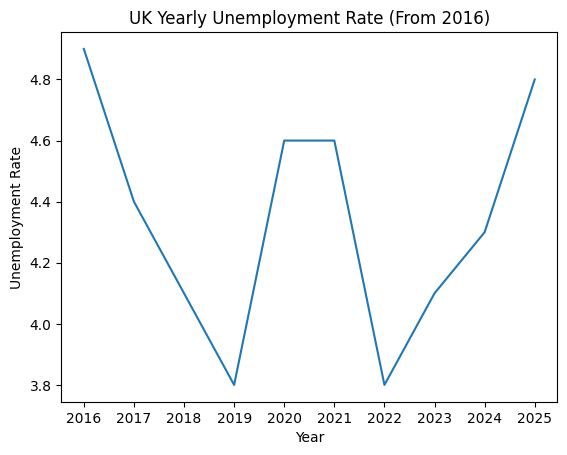

In [108]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(yearly_df["Year"], yearly_df["Unemployment rate (%)"])
plt.xlabel("Year")
plt.ylabel("Unemployment Rate")
plt.title("UK Yearly Unemployment Rate (From 2016)")
plt.xticks(yearly_df["Year"])
plt.show()

# Feature Engineering

# Modelling ??

# Insights & Conclusion